**We need a predicting model so that bank can focus more on potential converters, ie, people who will take loan, than people who will not take the loan**

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel("C:\\Users\\bhavy\\OneDrive\\Desktop\\Projects\\Bank Personal Loan\\Bank_Personal_Loan_Modelling.xlsx",sheet_name=1)

In [3]:
data = df.copy()
data = data.drop(['ID','ZIP Code'],axis=1)

In [4]:
data = data[['Age', 'Experience', 'Income', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Securities Account',
       'CD Account', 'Online', 'CreditCard','Personal Loan']]

In [5]:
data = data[data['Experience'] >= 0]

In [6]:
data.shape

(4948, 12)

In [7]:
data['CCToIncomeRatio'] = data['CCAvg'] / (data['Income']/12)

In [8]:
data = data[['Age','Experience', 'Income', 'Family', 'CCAvg',
       'Education', 'Mortgage','Securities Account', 'CD Account', 'Online',
       'CreditCard','CCToIncomeRatio','Personal Loan']]

In [9]:
data.sample(4)

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,CCToIncomeRatio,Personal Loan
1987,56,31,52,3,2.0,2,0,1,1,1,1,0.461538,0
823,35,9,45,1,2.0,1,0,0,0,1,1,0.533333,0
992,34,9,93,1,0.0,1,0,0,0,1,0,0.000000,0
4843,61,34,41,4,2.5,2,0,0,0,1,0,0.731707,0


Imp features by EDA:- Age,Income,CDAccount,Mortgage,Education,CCAvg,CCToIncomeRatio

In [10]:
data = data[['Age','Income','CD Account','Mortgage','Education','CCAvg','CCToIncomeRatio','Personal Loan']]

# For Logistic Model

Scaling :- Age,Income,Mortgage,CCAvg, CCToIncomeRatio

OneHotEncoding :- CD Account

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='CCToIncomeRatio', ylabel='Density'>

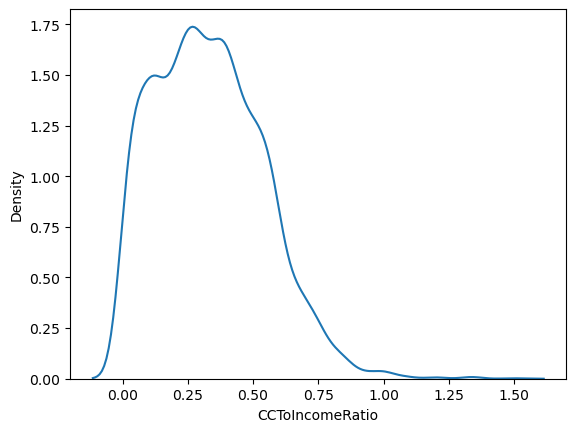

In [12]:
sns.kdeplot(data['CCToIncomeRatio'])

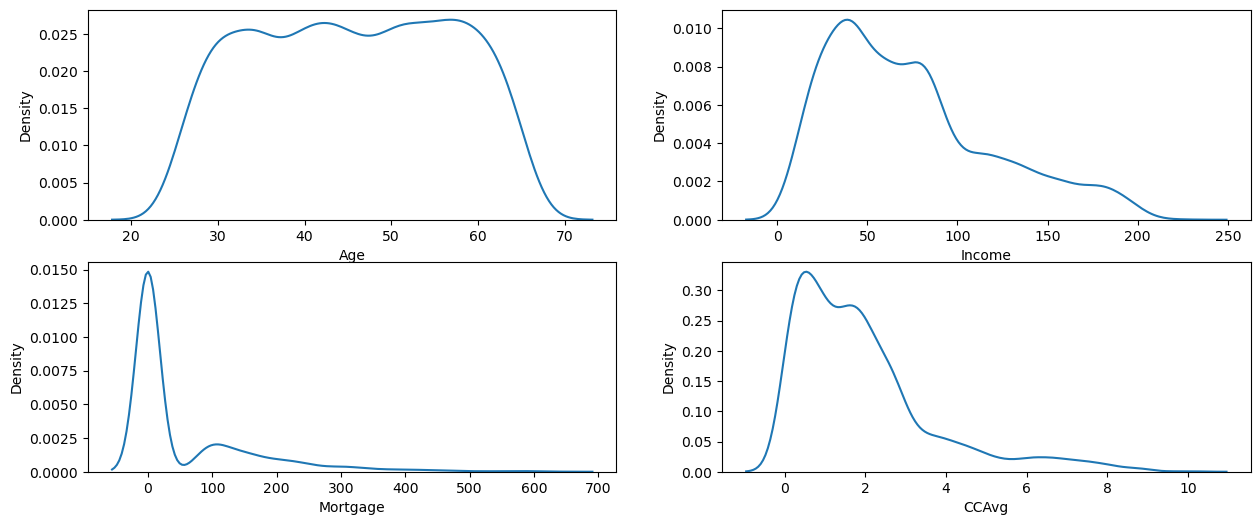

In [13]:
scaling = ['Age','Income','Mortgage','CCAvg']

plt.figure(figsize=(15,6))

for i, f in enumerate(scaling, start=1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data[f])

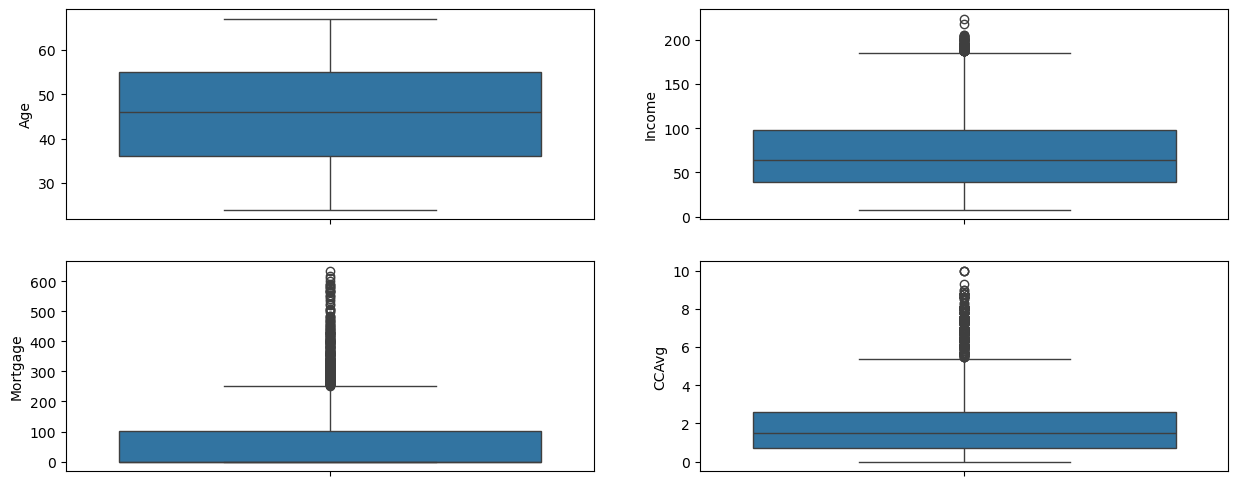

In [14]:
plt.figure(figsize=(15,6))

for i, f in enumerate(scaling, start=1):
    plt.subplot(2, 2, i)
    sns.boxplot(data[f])

We use StandardScaler on Age and CCToIncomeRatio and Robust Scaler on the rest of the three

In [15]:
data.sample()

,Age,Income,CD Account,Mortgage,Education,CCAvg,CCToIncomeRatio,Personal Loan
2165,27,38,0,154,3,1.0,0.315789,0


# Splitting data into Training and Testing data

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [18]:
X.shape

(4948, 7)

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [20]:
print(X_train.shape)
X_test.shape

(3711, 7)


(1237, 7)

# Creating a pipeline

In [21]:
from imblearn.over_sampling import SMOTENC

In [22]:
smotenc = SMOTENC(categorical_features=[2,4],random_state=42)

In [23]:
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [24]:
Transformer = ColumnTransformer([
    ('StandardScaling',StandardScaler(),['Age','CCToIncomeRatio']),
    ('RobustScaling',RobustScaler(),['Income','Mortgage','CCAvg']),
    ('OHE',OneHotEncoder(drop='first',sparse_output=False),['CD Account'])
],remainder='passthrough')

Preprocessing done.

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
from imblearn.pipeline import Pipeline    # Not using sklearn's pipeline, because it does not work with SMOTENC

In [27]:
Logistic_pipe = Pipeline(
    [('Imbalance Handling',smotenc),
     ('Preprocessing',Transformer),
     ('Logistic Model',LogisticRegression())
    ]
)

In [28]:
# Logistic_pipe.fit(X_train,y_train)

**Logistic Regression Pipeline created. Now fit it in the grid**

In [29]:
from sklearn.model_selection import GridSearchCV

**False Positives** :- In actual the person did not take loan but the model predicts he/she took the loan. Waste of resources and time

**False Negatives** :- Person took the loan but the model predicted it did not. Waste of potential income for the bank.


False Negative error is more dangerous than False positive error, hence we use **recall_score** in GridSearch's scoring parameter

In [30]:
Logistic_parameters = {
    'Logistic Model__C':[100,10,1,0.1,0.01]
    }

Logistic_grid = GridSearchCV(Logistic_pipe,param_grid=Logistic_parameters,scoring='recall')

In [31]:
Logistic_grid.fit(X_train,y_train)

C:\Users\bhavy\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('Imbalance Handling',
                                        SMOTENC(categorical_features=[2, 4],
                                                random_state=42)),
                                       ('Preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('StandardScaling',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'CCToIncomeRatio']),
                                                                        ('RobustScaling',
                                                                         RobustScaler(),
                                                                         ['Income',
                                                                          'Mortgage',
                                                                          'CCAvg']),
                                                                        ('OHE',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['CD '
                                                                          'Account'])])),
                                       ('Logistic Model',
                                        LogisticRegression())]),
             param_grid={'Logistic Model__C': [100, 10, 1, 0.1, 0.01]},
             scoring='recall')

In [32]:
Logistic_grid.best_params_

{'Logistic Model__C': 0.01}

In [33]:
y_preds = Logistic_grid.predict(X_test)

**Now we use metrics to see how LogisticRegression performed**

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

In [35]:
print('Confusion Matrix for Logistic with SMOTENC')
print(confusion_matrix(y_test,y_preds))

Confusion Matrix for Logistic with SMOTENC
[[1009  123]
 [  17   88]]


In [36]:
print('Classification report for Logistic with SMOTENC')
print(classification_report(y_test,y_preds))

Classification report for Logistic with SMOTENC
              precision    recall  f1-score   support

           0       0.98      0.89      0.94      1132
           1       0.42      0.84      0.56       105

    accuracy                           0.89      1237
   macro avg       0.70      0.86      0.75      1237
weighted avg       0.94      0.89      0.90      1237



# Now for RFC

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
# Pipeline for RFC

RFC_pipe = Pipeline(
    [('Imbalance handling',smotenc),
     ('RFC Model',RandomForestClassifier())
    ]
)

In [39]:
RFC_parameters = {
    'RFC Model__n_estimators':[50,100,300],
    'RFC Model__criterion':['gini', 'entropy', 'log_loss'],
    'RFC Model__max_depth':[5,10,20],
    'RFC Model__min_samples_split':[2,5,10],
    'RFC Model__min_samples_leaf':[1,2,5],
    'RFC Model__max_features':['sqrt','log2'],
    }

RFC_grid = GridSearchCV(RFC_pipe,param_grid=RFC_parameters,scoring='recall',n_jobs=-1)

In [40]:
RFC_grid.fit(X_train,y_train)

GridSearchCV(estimator=Pipeline(steps=[('Imbalance handling',
                                        SMOTENC(categorical_features=[2, 4],
                                                random_state=42)),
                                       ('RFC Model',
                                        RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'RFC Model__criterion': ['gini', 'entropy',
                                                  'log_loss'],
                         'RFC Model__max_depth': [5, 10, 20],
                         'RFC Model__max_features': ['sqrt', 'log2'],
                         'RFC Model__min_samples_leaf': [1, 2, 5],
                         'RFC Model__min_samples_split': [2, 5, 10],
                         'RFC Model__n_estimators': [50, 100, 300]},
             scoring='recall')

In [41]:
RFC_grid.best_params_

{'RFC Model__criterion': 'log_loss',
 'RFC Model__max_depth': 5,
 'RFC Model__max_features': 'log2',
 'RFC Model__min_samples_leaf': 5,
 'RFC Model__min_samples_split': 2,
 'RFC Model__n_estimators': 100}

In [42]:
RFC_y_preds = RFC_grid.predict(X_test)

In [43]:
print('Confusion Matrix for RFC')
print(confusion_matrix(y_test,RFC_y_preds))

Confusion Matrix for RFC
[[1024  108]
 [   2  103]]


In [44]:
print('Classification report for RFC')
print(classification_report(y_test,RFC_y_preds))

Classification report for RFC
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      1132
           1       0.49      0.98      0.65       105

    accuracy                           0.91      1237
   macro avg       0.74      0.94      0.80      1237
weighted avg       0.95      0.91      0.92      1237



**Accuracy is a bad metric here, since its heavily dominated by True Negatives. Moreover, its better to have a model with very high recall score, which means it is very unlikely to miss a potential loan taker. This means the bank can very linkely identify loan takers without missing a potential customer. False positives also lead to some losses, but the revenue from loan is more effective than losses by campaigning to people who are less likely to take the loan**

# Now comparing ROC-AUC Curves of Logistic and RandomForestClassifier

In [45]:
# Logistic_grid,  RFC_grid

Logistic_y_scores = Logistic_grid.predict_proba(X_test)[:,1]
RFC_y_scores = RFC_grid.predict_proba(X_test)[:,1]

In [46]:
Logistic_y_scores.shape

(1237,)

In [47]:
from sklearn.metrics import roc_curve,roc_auc_score

logistic_fpr, logistic_tpr, logistic_thresholds = roc_curve(y_test, Logistic_y_scores)
RFC_fpr, RFC_tpr, RFC_thresholds = roc_curve(y_test, RFC_y_scores)

In [48]:
# AUC scores
logistic_auc = roc_auc_score(y_test, Logistic_y_scores)
rfc_auc = roc_auc_score(y_test, RFC_y_scores)

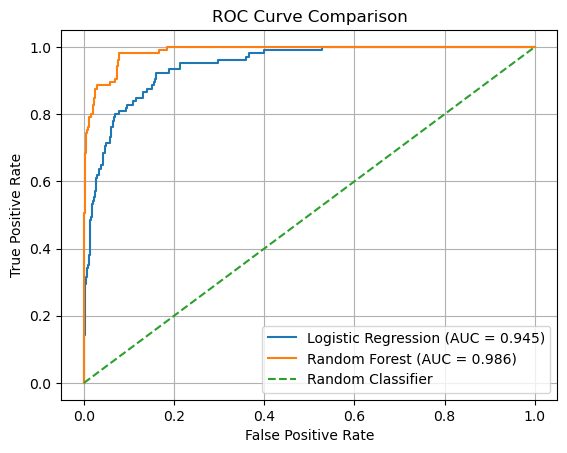

In [49]:
plt.figure()
plt.plot(logistic_fpr, logistic_tpr, label=f'Logistic Regression (AUC = {logistic_auc:.3f})')
plt.plot(RFC_fpr, RFC_tpr, label=f'Random Forest (AUC = {rfc_auc:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Confusion matrix shows that RFC has a better recall score, which is what we need in our case**

**Additionally,the ROC_AUC also shows that RFC performs better overall across all threshold values since it has more area**

**RFC is a better model**

In [53]:
final_rfc_model = RFC_grid.best_estimator_

In [55]:
final_rfc_model

Pipeline(steps=[('Imbalance handling',
                 SMOTENC(categorical_features=[2, 4], random_state=42)),
                ('RFC Model',
                 RandomForestClassifier(criterion='log_loss', max_depth=5,
                                        max_features='log2',
                                        min_samples_leaf=5))])

In [57]:
# import pickle

# save using pickle


# with open("final_rfc_model.pkl", "wb") as f:
    # pickle.dump(final_rfc_model, f)